In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import spearmanr

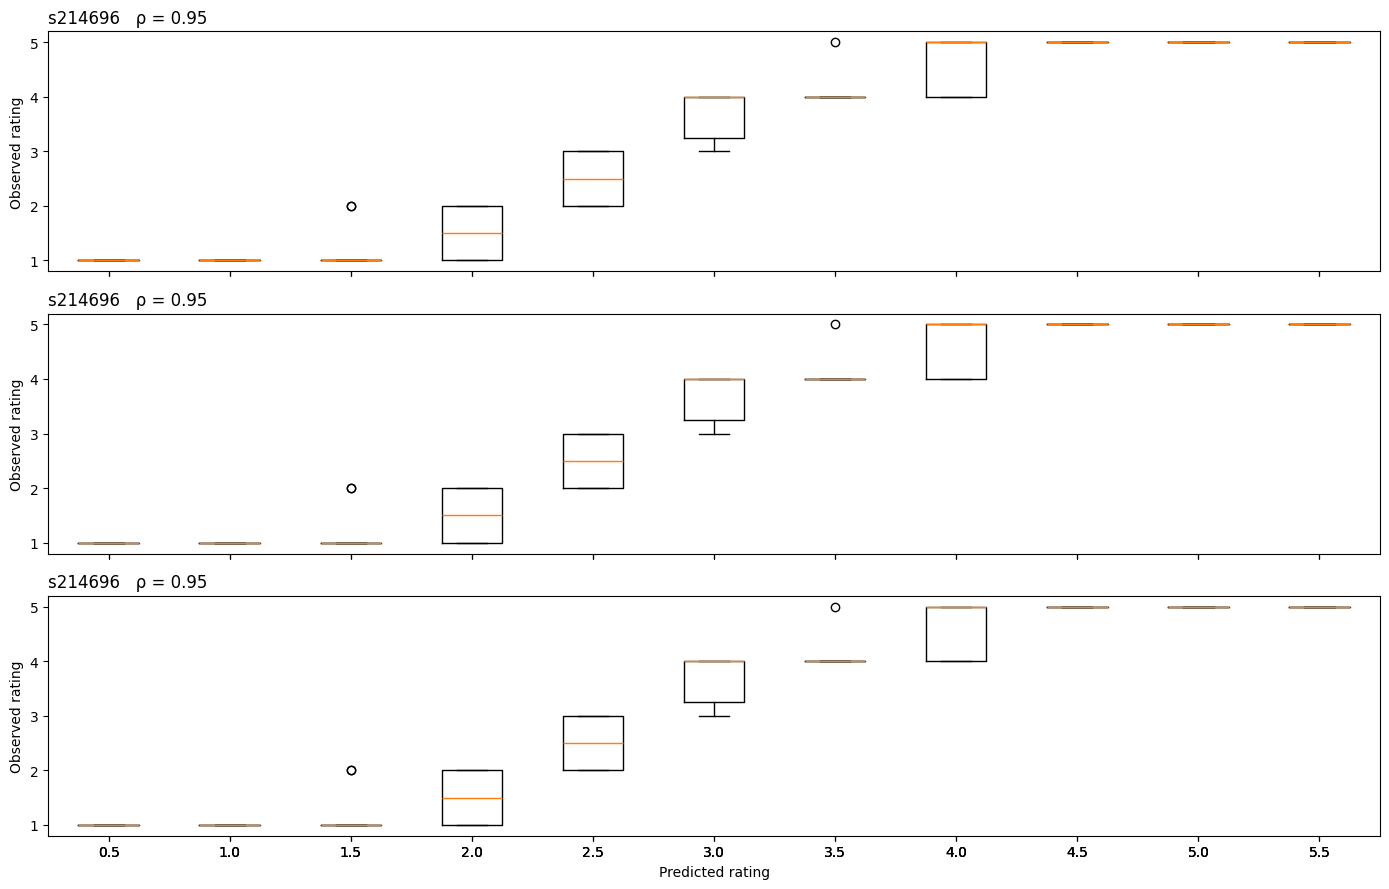

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import spearmanr

STUDY_NRS = ["s214696", "s214696", "s214696"]

fig, axes = plt.subplots(3, 1, figsize=(14, 9), sharex=True, sharey=True)

for ax, nr in zip(axes, STUDY_NRS):
    df = pd.read_csv(f"experiment_2_{nr}.csv")
    df["predicted"] = df["filename"].str[5:-4].astype(float)
    df = df.sort_values("predicted")

    cols = df.filter(like="rating_").columns
    data = [row.dropna().values for _, row in df[cols].iterrows()]

    ax.boxplot(data, tick_labels=df["predicted"])
    ax.set_ylabel("Observed rating")

    long = df.melt(id_vars="predicted", value_vars=cols).dropna()
    rho, p = spearmanr(long["predicted"], long["value"])
    ax.set_title(f"{nr}   ρ = {rho:.2f}", loc="left")

axes[-1].set_xlabel("Predicted rating")
plt.tight_layout()
plt.savefig("experiment2_boxplots.png", dpi=200)
plt.show()